# Group_21

> 需在[完整项目框架](https://github.com/ScH01ar/cv-emnist)中运行

## 目录

a. Step 1 - Step 4

b. MLP

c. CNNs

d. ResNet

e. Vision Transformer

f. Step 6

## a. Step 1 - Step 4

本部分对应作业要求中的基础步骤：

1. 说明导入的包/库
2. 加载数据集
3. 构建训练集和测试集的 DataLoader
4. 输出训练集和测试集样本数量，并可视化部分图像样本

In [3]:
# 公共导包。
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

# 公共路径和默认参数。
PROJECT_ROOT = Path(".")
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
RUNS_DIR = PROJECT_ROOT / "runs"
BEST_RUNS_DIR = PROJECT_ROOT / "artifacts" / "best_runs"

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_WORKERS = 0

# 固定随机种子，保证 notebook 中展示结果可复现。
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 定义 EMNIST 图像方向修正变换。
class EMNISTOrientationCorrection:
    def __call__(self, tensor):
        tensor = torch.rot90(tensor, -1, dims=[1, 2])
        tensor = torch.flip(tensor, dims=[1])
        return tensor

# 读取 JSON 文件。
def load_json(path):
    return json.loads(Path(path).read_text())

# 读取单个 run 的 summary / test_metrics / history。
def load_run_bundle(run_name, root=RUNS_DIR):
    run_dir = Path(root) / run_name
    history_path = run_dir / "history.json"
    return {
        "run_dir": run_dir,
        "summary": load_json(run_dir / "summary.json"),
        "test_metrics": load_json(run_dir / "test_metrics.json"),
        "history": load_json(history_path) if history_path.exists() else None,
    }

# 把单个 run 压成一行结果，方便后续做表格。
def summarize_run(run_name, root=RUNS_DIR, **extra):
    bundle = load_run_bundle(run_name, root=root)
    summary = bundle["summary"]
    test_metrics = bundle["test_metrics"]
    row = {
        "run_name": run_name,
        "best_val_acc": round(summary["best_val_accuracy"] * 100, 2),
        "test_acc": round(test_metrics["accuracy"] * 100, 2),
        "test_loss": round(test_metrics["loss"], 4),
    }
    row.update(extra)
    return row

# 根据配置列表批量构建结果表。
def build_result_table(specs, root=RUNS_DIR):
    rows = []
    for spec in specs:
        spec = spec.copy()
        run_name = spec.pop("run_name")
        rows.append(summarize_run(run_name, root=root, **spec))
    return rows

# 统一展示结果表；如果有 pandas 就显示成 DataFrame，否则打印字典。
def show_table(rows, title=None):
    if title:
        print(f"\n{title}")
    if pd is not None:
        df = pd.DataFrame(rows)
        if display is not None:
            display(df)
        else:
            print(df.to_string(index=False))
        return df
    for row in rows:
        print(row)
    return rows

# 绘制双指标柱状图，后面可复用于增强前后对比等场景。
def plot_metric_bars(rows, label_key, left_key, right_key, title, ylabel="Accuracy (%)"):
    labels = [row[label_key] for row in rows]
    left_values = [row[left_key] for row in rows]
    right_values = [row[right_key] for row in rows]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4.5))
    plt.bar(x - width / 2, left_values, width=width, label=left_key)
    plt.bar(x + width / 2, right_values, width=width, label=right_key)
    plt.xticks(x, labels, rotation=10)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 读取 best_runs 下某个模型保存的最佳结果。
def load_best_bundle(model_name):
    model_dir = BEST_RUNS_DIR / model_name
    return {
        "summary": load_json(model_dir / "summary.json"),
        "test_metrics": load_json(model_dir / "test_metrics.json"),
        "history": load_json(model_dir / "history.json"),
    }

# 缺失值保持为 None，避免把“未记录”误显示成 0。
def round_or_none(value, digits=2):
    return None if value is None else round(value, digits)

# 汇总某个最佳模型的关键指标。
def summarize_best_bundle(model_name):
    bundle = load_best_bundle(model_name)
    summary = bundle["summary"]
    test_metrics = bundle["test_metrics"]
    memory = summary.get("memory", {})
    return {
        "model": model_name,
        "best_epoch": summary["best_epoch"],
        "best_val_acc": round(summary["best_val_accuracy"] * 100, 2),
        "test_acc": round(test_metrics["accuracy"] * 100, 2),
        "test_loss": round(test_metrics["loss"], 4),
        "training_seconds": round(summary["training_seconds"], 2),
        "cpu_peak_rss_mb": round_or_none(memory.get("cpu_peak_rss_mb")),
        "gpu_peak_allocated_mb": round_or_none(memory.get("gpu_peak_allocated_mb")),
        "gpu_peak_reserved_mb": round_or_none(memory.get("gpu_peak_reserved_mb")),
    }

# 绘制训练过程中的 loss 和 accuracy 曲线。
def plot_history_curves(history, title_prefix):
    epochs = [item["epoch"] for item in history]
    train_loss = [item["train_loss"] for item in history]
    val_loss = [item["val_loss"] for item in history]
    train_acc = [item["train_accuracy"] * 100 for item in history]
    val_acc = [item["val_accuracy"] * 100 for item in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, train_loss, label="train loss")
    axes[0].plot(epochs, val_loss, label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title_prefix} loss curve")
    axes[0].legend()

    axes[1].plot(epochs, train_acc, label="train accuracy")
    axes[1].plot(epochs, val_acc, label="val accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title_prefix} accuracy curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 统一展示小样本实验结果。
def show_small_data_summary(summary_path):
    summary_path = Path(summary_path)
    if not summary_path.exists():
        print(f"Small-data summary not found: {summary_path}")
        return None
    data = load_json(summary_path)
    return show_table(data, title="Small-data results")

# 把数值标签解码成字符标签。
def decode_label(dataset, label):
    return dataset.classes[int(label)]

# 可视化若干数据集样本。
def show_samples(dataset, rows=2, cols=6, seed=SEED):
    random.seed(seed)
    total = rows * cols
    indices = random.sample(range(len(dataset)), total)

    fig, axes = plt.subplots(rows, cols, figsize=(1.8 * cols, 2.2 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax, idx in zip(axes.flat, indices):
        image, label = dataset[idx]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(f"label: {decode_label(dataset, label)}", fontsize=10)
        ax.axis("off")

    plt.suptitle("EMNIST Balanced Sample Images", fontsize=14)
    plt.tight_layout()
    plt.show()

set_seed()
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT.resolve()}")


Device: cuda
Project root: /home/yanyu/homework/cv/cv-emnist


Data root: /home/yanyu/homework/cv/cv-emnist/data/raw
Number of training samples: 112,800
Number of test samples: 18,800
Number of classes: 47
Train batch image shape: (128, 1, 28, 28)
Train batch label shape: (128,)


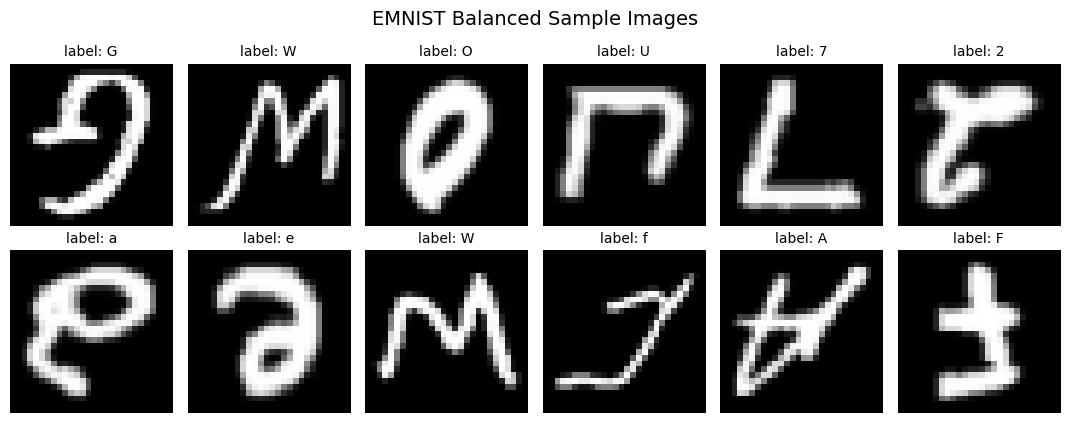

In [4]:
# 定义基础预处理流程；这里只做张量化和方向修正，便于直接可视化原始样本。
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    EMNISTOrientationCorrection(),
])

# 下载并加载 EMNIST Balanced 训练集和测试集。
train_dataset = datasets.EMNIST(
    root=str(DATA_ROOT),
    split="balanced",
    train=True,
    download=True,
    transform=basic_transform,
)

test_dataset = datasets.EMNIST(
    root=str(DATA_ROOT),
    split="balanced",
    train=False,
    download=True,
    transform=basic_transform,
)

# 构建训练集和测试集的 DataLoader。
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 输出训练集与测试集中的样本数量，以及类别数量。
print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Number of training samples: {len(train_dataset):,}")
print(f"Number of test samples: {len(test_dataset):,}")
print(f"Number of classes: {len(train_dataset.classes)}")

# 查看一个训练 batch 的张量形状，说明 DataLoader 的输出格式。
sample_images, sample_labels = next(iter(train_loader))
print(f"Train batch image shape: {tuple(sample_images.shape)}")
print(f"Train batch label shape: {tuple(sample_labels.shape)}")

# 可视化部分训练集样本。
show_samples(train_dataset)


## b. MLP

本部分只展示 MLP 的模型实现、最终最优配置、简短调参过程说明，以及基于 `artifacts/best_runs/mlp/` 的最终结果展示。训练本身不在 notebook 中重复实现。


In [5]:
# MLP 模型实现（直接对应 models/mlp.py）
from torch import nn


def build_activation(name: str) -> nn.Module:
    key = name.lower()
    if key == "relu":
        return nn.ReLU()
    if key == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.1)
    if key == "elu":
        return nn.ELU()
    if key == "gelu":
        return nn.GELU()
    if key == "silu":
        return nn.SiLU()
    raise ValueError(f"Unsupported activation: {name}")


def build_norm(name: str, hidden_dim: int) -> nn.Module | None:
    key = name.lower()
    if key == "none":
        return None
    if key == "batchnorm":
        return nn.BatchNorm1d(hidden_dim)
    if key == "layernorm":
        return nn.LayerNorm(hidden_dim)
    raise ValueError(f"Unsupported normalization: {name}")


class MLP(nn.Module):
    def __init__(
        self,
        num_classes: int = 47,
        input_dim: int = 28 * 28,
        hidden_dims: list[int] | tuple[int, ...] = (512, 256, 128),
        activation: str = "relu",
        norm: str = "none",
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        layers = [nn.Flatten()]
        in_features = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            norm_layer = build_norm(norm, hidden_dim)
            if norm_layer is not None:
                layers.append(norm_layer)
            layers.append(build_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


### MLP 最优配置

配置来源：`configs/mlp/stage4_regularization_l1_aug.yaml`

```yaml
seed: 42
device: auto

data:
  batch_size: 128
  val_ratio: 0.1
  num_workers: 4
  augmentation:
    enabled: true
    rotation_deg: 10
    translate: 0.05
    gaussian_noise_std: 0.02

model:
  file: models/mlp.py
  class_name: MLP
  kwargs:
    hidden_dims: [512, 256, 128]
    activation: relu
    norm: batchnorm
    dropout: 0.2

train:
  run_name: mlp_stage4_regularization_l1_aug
  epochs: 100
  optimizer:
    name: adam
    lr: 0.001
    weight_decay: 0.0
    momentum: 0.9
  scheduler:
    name: plateau
    patience: 2
    factor: 0.5
    min_lr: 0.000001
  regularization:
    type: l1
    l1_lambda: 0.00001
    l2_lambda: 0.0
```


### MLP 训练框架与探索过程

训练统一复用项目公共框架：
- 数据接口：`src/dataset.py`
- 训练与评估：`src/trainer.py`
- 训练入口：`src/main.py`
- 组员在本地使用配置文件训练，再把最优结果保存到 `artifacts/best_runs/mlp/`

MLP 的调参过程依据 [docs/mlp_tuning_summary.md](/home/yanyu/homework/cv/cv-emnist/docs/mlp_tuning_summary.md) 简要总结如下：
- 初始 baseline 使用 `relu + adam + step + no norm + dropout(0.2) + no regularization`
- 第一轮先单独探索六类训练技术，发现 `BatchNorm` 带来的提升最稳定，因此先固定下来
- 第二轮在 `BatchNorm` 基础上继续比较调度器，`plateau` 优于原来的 `step`，也略优于 `cosine`
- 第三轮继续比较激活函数、优化器、正则化和 Dropout，最终保留 `ReLU + Adam + L1 + dropout(0.2)`
- 最后在当前最优配置上加入数据增强，最终测试准确率从 baseline 的 `86.52%` 提升到 `88.65%`，提升 `2.13` 个百分点
- 下面先展示 MLP 在 30% / 50% / 100% 训练数据下的小样本结果；跨模型比较放到后续统一公共实验部分展示


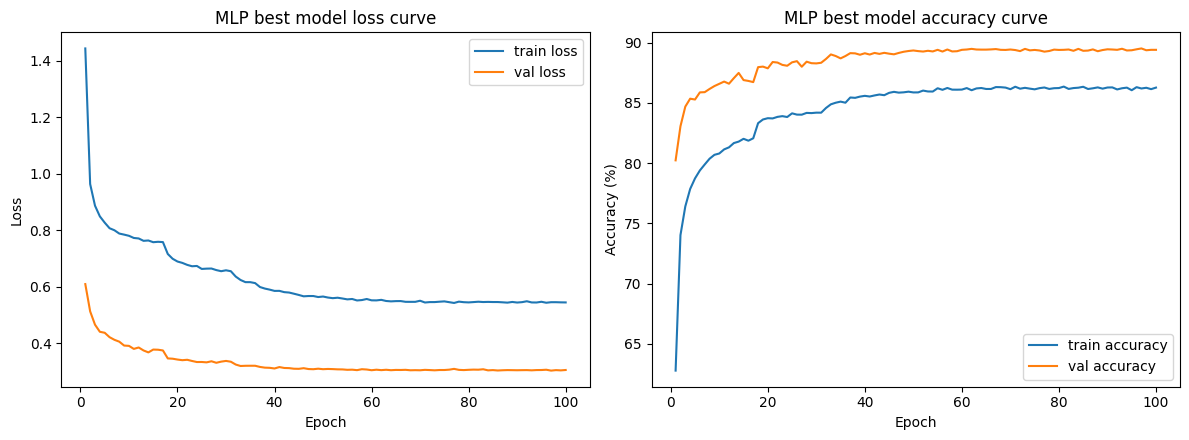


MLP best run summary
{'model': 'mlp', 'best_epoch': 97, 'best_val_acc': 89.51, 'test_acc': 88.65, 'test_loss': 0.3218, 'training_seconds': 2055.25, 'cpu_peak_rss_mb': 1339.86, 'gpu_peak_allocated_mb': 31.61, 'gpu_peak_reserved_mb': 48.0}


[{'model': 'mlp',
  'best_epoch': 97,
  'best_val_acc': 89.51,
  'test_acc': 88.65,
  'test_loss': 0.3218,
  'training_seconds': 2055.25,
  'cpu_peak_rss_mb': 1339.86,
  'gpu_peak_allocated_mb': 31.61,
  'gpu_peak_reserved_mb': 48.0}]

In [6]:
# Step 5.c: 读取 best run，绘制 MLP 的 loss / accuracy 曲线，并汇总训练时间与内存占用。
mlp_bundle = load_best_bundle("mlp")
plot_history_curves(mlp_bundle["history"]["history"], title_prefix="MLP best model")
show_table([summarize_best_bundle("mlp")], title="MLP best run summary")



MLP small-data summary
{'train_ratio_pct': 30, 'run_name': 'mlp_small_30', 'best_epoch': 50, 'best_val_acc': 87.73, 'test_acc': 86.82, 'test_loss': 0.3819, 'training_seconds': 314.91}
{'train_ratio_pct': 50, 'run_name': 'mlp_small_50', 'best_epoch': 48, 'best_val_acc': 88.55, 'test_acc': 87.7, 'test_loss': 0.3572, 'training_seconds': 496.9}
{'train_ratio_pct': 100, 'run_name': 'mlp_small_100', 'best_epoch': 50, 'best_val_acc': 89.34, 'test_acc': 88.42, 'test_loss': 0.3266, 'training_seconds': 947.92}


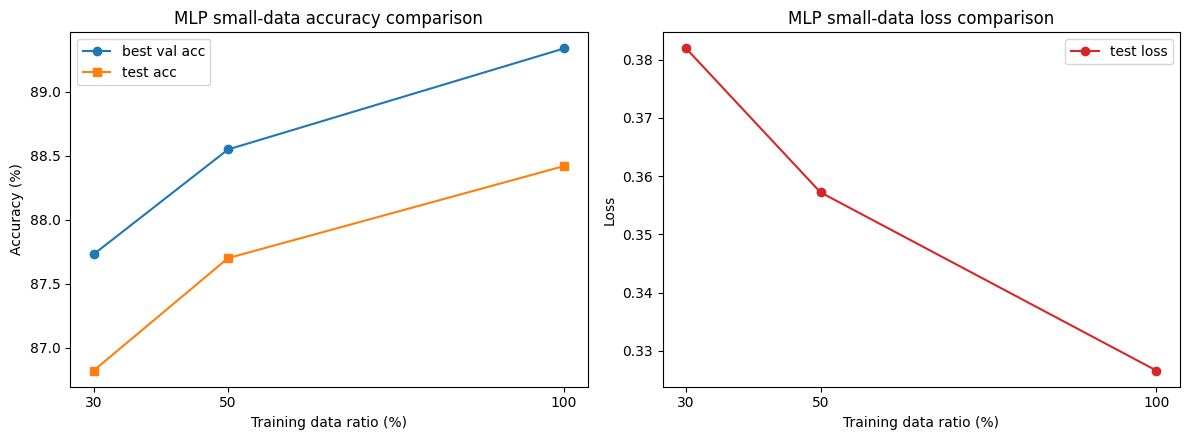


Trend summary:
- test accuracy changes from 86.82% at 30% data to 88.42% at 100% data.
- test loss changes from 0.3819 at 30% data to 0.3266 at 100% data.


In [7]:
# Step 5.d: 展示 MLP 在 30% / 50% / 100% 训练数据下的小样本结果。
from pathlib import Path
import json
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

RUNS_DIR_LOCAL = Path('runs')


def load_json_local(path):
    return json.loads(Path(path).read_text())


def show_table_local(rows, title=None):
    if title:
        print(f"\n{title}")
    if pd is not None:
        df = pd.DataFrame(rows)
        if display is not None:
            display(df)
        else:
            print(df.to_string(index=False))
        return df
    for row in rows:
        print(row)
    return rows


mlp_small_specs = [
    (30, 'mlp_small_30'),
    (50, 'mlp_small_50'),
    (100, 'mlp_small_100'),
]

mlp_small_rows = []
mlp_small_missing = []

for ratio, run_name in mlp_small_specs:
    run_dir = RUNS_DIR_LOCAL / run_name
    required_files = [run_dir / 'summary.json', run_dir / 'test_metrics.json', run_dir / 'history.json']
    missing_files = [file_path.name for file_path in required_files if not file_path.exists()]
    if missing_files:
        mlp_small_missing.append({'run_name': run_name, 'missing_files': missing_files})
        continue

    summary = load_json_local(run_dir / 'summary.json')
    test_metrics = load_json_local(run_dir / 'test_metrics.json')
    mlp_small_rows.append(
        {
            'train_ratio_pct': ratio,
            'run_name': run_name,
            'best_epoch': summary['best_epoch'],
            'best_val_acc': round(summary['best_val_accuracy'] * 100, 2),
            'test_acc': round(test_metrics['accuracy'] * 100, 2),
            'test_loss': round(test_metrics['loss'], 4),
            'training_seconds': round(summary['training_seconds'], 2),
        }
    )

if mlp_small_missing:
    print('The following MLP small-data runs are incomplete or missing:')
    for item in mlp_small_missing:
        print(f"- {item['run_name']}: missing {', '.join(item['missing_files'])}")

if mlp_small_rows:
    mlp_small_rows = sorted(mlp_small_rows, key=lambda row: row['train_ratio_pct'])
    show_table_local(mlp_small_rows, title='MLP small-data summary')

    x = [row['train_ratio_pct'] for row in mlp_small_rows]
    val_acc = [row['best_val_acc'] for row in mlp_small_rows]
    test_acc = [row['test_acc'] for row in mlp_small_rows]
    test_loss = [row['test_loss'] for row in mlp_small_rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(x, val_acc, marker='o', label='best val acc')
    axes[0].plot(x, test_acc, marker='s', label='test acc')
    axes[0].set_xlabel('Training data ratio (%)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('MLP small-data accuracy comparison')
    axes[0].set_xticks(x)
    axes[0].legend()

    axes[1].plot(x, test_loss, marker='o', color='tab:red', label='test loss')
    axes[1].set_xlabel('Training data ratio (%)')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('MLP small-data loss comparison')
    axes[1].set_xticks(x)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    if len(mlp_small_rows) >= 2:
        first = mlp_small_rows[0]
        last = mlp_small_rows[-1]
        print()
        print('Trend summary:')
        print(
            f"- test accuracy changes from {first['test_acc']:.2f}% at {first['train_ratio_pct']}% data "
            f"to {last['test_acc']:.2f}% at {last['train_ratio_pct']}% data."
        )
        print(
            f"- test loss changes from {first['test_loss']:.4f} at {first['train_ratio_pct']}% data "
            f"to {last['test_loss']:.4f} at {last['train_ratio_pct']}% data."
        )
else:
    print('No completed MLP small-data runs were found in runs/.')


## c. CNNs

本部分只展示 CNN 的模型实现、最终最优配置、简短调参过程说明，以及基于 `artifacts/best_runs/cnn/` 的最终结果展示。训练本身不在 notebook 中重复实现。


In [8]:
# CNN 模型实现（直接对应 models/cnn.py）
from __future__ import annotations
import torch
from torch import nn


def build_activation(name: str) -> nn.Module:
    key = name.lower()
    if key == "relu": return nn.ReLU()
    if key == "leaky_relu": return nn.LeakyReLU(negative_slope=0.1)
    if key == "elu": return nn.ELU()
    if key == "gelu": return nn.GELU()
    if key == "silu": return nn.SiLU()
    raise ValueError(f"Unsupported activation: {name}")


def build_norm2d(name: str, num_features: int) -> nn.Module | None:
    key = name.lower()
    if key == "none": return None
    if key == "batchnorm": return nn.BatchNorm2d(num_features)
    raise ValueError(f"Unsupported/Unimplemented normalization for 2D: {name}")


class CNN(nn.Module):
    def __init__(
        self,
        num_classes: int = 47,
        activation: str = "relu",
        norm: str = "none",
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            build_norm2d(norm, 32) if build_norm2d(norm, 32) else nn.Identity(),
            build_activation(activation),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            build_norm2d(norm, 64) if build_norm2d(norm, 64) else nn.Identity(),
            build_activation(activation),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            build_activation(activation),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### CNN 最优配置

配置来源：`artifacts/best_runs/cnn/config.yaml`

```yaml
seed: 42
device: auto

data:
  batch_size: 128
  val_ratio: 0.1
  num_workers: 0

model:
  file: models/cnn.py
  class_name: CNN
  kwargs:
    activation: gelu
    norm: batchnorm
    dropout: 0.2

train:
  run_name: cnn_adam_step_gelu
  epochs: 15
  optimizer:
    name: adam
    lr: 0.001
    weight_decay: 0.01
  scheduler:
    name: step
    step_size: 5
    gamma: 0.1
  regularization:
    type: l2
    l2_lambda: 0.0001
```


### CNN 训练框架与探索过程

训练同样统一复用项目公共框架：`src/dataset.py + src/trainer.py + src/main.py`。组员在本地训练后，将最佳结果归档到 `artifacts/best_runs/cnn/`。

CNN 的调参过程依据 [docs/cnn_resnet_tuning_summary.md](/home/yanyu/homework/cv/cv-emnist/docs/cnn_resnet_tuning_summary.md) 简要总结如下：
- 初始 baseline 使用 `relu + batchnorm + dropout(0.2) + adam + no scheduler + l2(1e-4)`
- 第一轮先探索优化器和调度器，最终确定 `adam + step` 作为主干训练组合
- 第二轮比较激活函数，最终保留 `gelu`
- 第三轮继续比较正则化、Dropout 和归一化，最终保留 `l2 + dropout(0.2) + batchnorm`
- 还测试了数据增强版本，但最终测试准确率不如未启用增强的版本，因此最终 best run 仍采用未增强配置
- 最终测试准确率从 baseline 的 `88.29%` 提升到 `89.14%`，提升 `0.85` 个百分点
- 下面继续展示 CNN 在 30% / 50% / 100% 训练数据下的小样本结果；跨模型比较放到后续统一公共实验部分展示


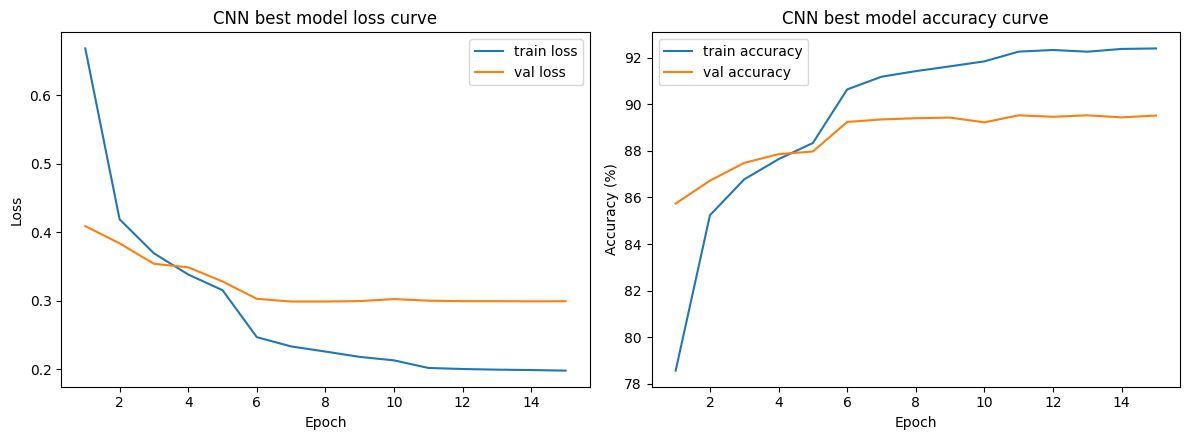


CNN best run summary
{'model': 'cnn', 'best_epoch': 13, 'best_val_acc': 89.52, 'test_acc': 89.14, 'test_loss': 0.3137, 'training_seconds': 563.82, 'cpu_peak_rss_mb': None, 'gpu_peak_allocated_mb': None, 'gpu_peak_reserved_mb': None}


[{'model': 'cnn',
  'best_epoch': 13,
  'best_val_acc': 89.52,
  'test_acc': 89.14,
  'test_loss': 0.3137,
  'training_seconds': 563.82,
  'cpu_peak_rss_mb': None,
  'gpu_peak_allocated_mb': None,
  'gpu_peak_reserved_mb': None}]

In [9]:
# Step 5.c: 读取 best run，绘制 CNN 的 loss / accuracy 曲线，并汇总训练时间与内存占用。
cnn_bundle = load_best_bundle("cnn")
plot_history_curves(cnn_bundle["history"]["history"], title_prefix="CNN best model")
show_table([summarize_best_bundle("cnn")], title="CNN best run summary")



CNN small-data summary
{'train_ratio_pct': 30, 'run_name': 'cnn_small_30', 'best_epoch': 14, 'best_val_acc': 87.7, 'test_acc': 87.29, 'test_loss': 0.3894, 'training_seconds': 116.68}
{'train_ratio_pct': 50, 'run_name': 'cnn_small_50', 'best_epoch': 15, 'best_val_acc': 88.81, 'test_acc': 88.08, 'test_loss': 0.35, 'training_seconds': 177.3}
{'train_ratio_pct': 100, 'run_name': 'cnn_small_100', 'best_epoch': 12, 'best_val_acc': 89.59, 'test_acc': 89.1, 'test_loss': 0.3141, 'training_seconds': 336.27}


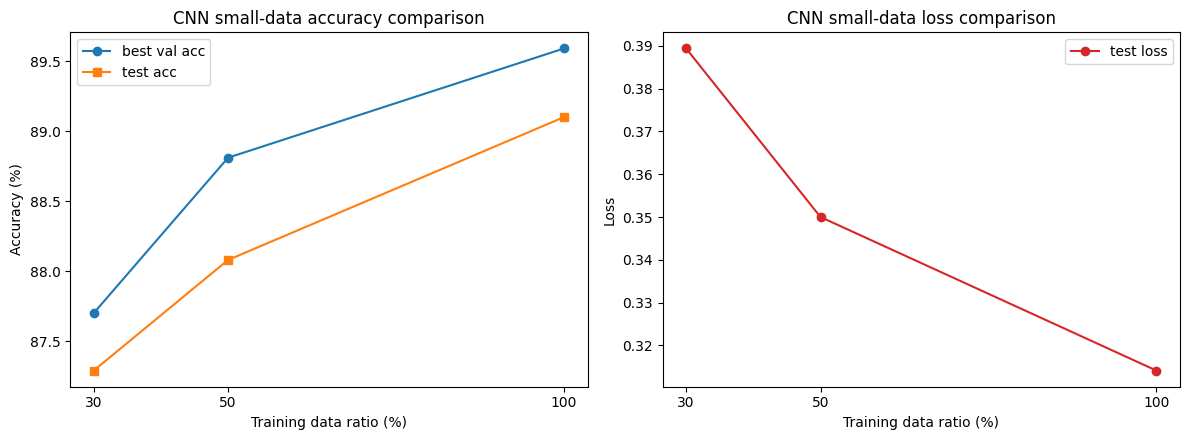


Trend summary:
- test accuracy changes from 87.29% at 30% data to 89.10% at 100% data.
- test loss changes from 0.3894 at 30% data to 0.3141 at 100% data.


In [10]:
# Step 5.d: 展示 CNN 在 30% / 50% / 100% 训练数据下的小样本结果。
from pathlib import Path
import json
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

RUNS_DIR_LOCAL = Path('runs')


def load_json_local(path):
    return json.loads(Path(path).read_text())


def show_table_local(rows, title=None):
    if title:
        print(f"\n{title}")
    if pd is not None:
        df = pd.DataFrame(rows)
        if display is not None:
            display(df)
        else:
            print(df.to_string(index=False))
        return df
    for row in rows:
        print(row)
    return rows


cnn_small_specs = [
    (30, 'cnn_small_30'),
    (50, 'cnn_small_50'),
    (100, 'cnn_small_100'),
]

cnn_small_rows = []
cnn_small_missing = []

for ratio, run_name in cnn_small_specs:
    run_dir = RUNS_DIR_LOCAL / run_name
    required_files = [run_dir / 'summary.json', run_dir / 'test_metrics.json', run_dir / 'history.json']
    missing_files = [file_path.name for file_path in required_files if not file_path.exists()]
    if missing_files:
        cnn_small_missing.append({'run_name': run_name, 'missing_files': missing_files})
        continue

    summary = load_json_local(run_dir / 'summary.json')
    test_metrics = load_json_local(run_dir / 'test_metrics.json')
    cnn_small_rows.append(
        {
            'train_ratio_pct': ratio,
            'run_name': run_name,
            'best_epoch': summary['best_epoch'],
            'best_val_acc': round(summary['best_val_accuracy'] * 100, 2),
            'test_acc': round(test_metrics['accuracy'] * 100, 2),
            'test_loss': round(test_metrics['loss'], 4),
            'training_seconds': round(summary['training_seconds'], 2),
        }
    )

if cnn_small_missing:
    print('The following CNN small-data runs are incomplete or missing:')
    for item in cnn_small_missing:
        print(f"- {item['run_name']}: missing {', '.join(item['missing_files'])}")

if cnn_small_rows:
    cnn_small_rows = sorted(cnn_small_rows, key=lambda row: row['train_ratio_pct'])
    show_table_local(cnn_small_rows, title='CNN small-data summary')

    x = [row['train_ratio_pct'] for row in cnn_small_rows]
    val_acc = [row['best_val_acc'] for row in cnn_small_rows]
    test_acc = [row['test_acc'] for row in cnn_small_rows]
    test_loss = [row['test_loss'] for row in cnn_small_rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(x, val_acc, marker='o', label='best val acc')
    axes[0].plot(x, test_acc, marker='s', label='test acc')
    axes[0].set_xlabel('Training data ratio (%)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('CNN small-data accuracy comparison')
    axes[0].set_xticks(x)
    axes[0].legend()

    axes[1].plot(x, test_loss, marker='o', color='tab:red', label='test loss')
    axes[1].set_xlabel('Training data ratio (%)')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('CNN small-data loss comparison')
    axes[1].set_xticks(x)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    if len(cnn_small_rows) >= 2:
        first = cnn_small_rows[0]
        last = cnn_small_rows[-1]
        print()
        print('Trend summary:')
        print(
            f"- test accuracy changes from {first['test_acc']:.2f}% at {first['train_ratio_pct']}% data "
            f"to {last['test_acc']:.2f}% at {last['train_ratio_pct']}% data."
        )
        print(
            f"- test loss changes from {first['test_loss']:.4f} at {first['train_ratio_pct']}% data "
            f"to {last['test_loss']:.4f} at {last['train_ratio_pct']}% data."
        )
else:
    print('No completed CNN small-data runs were found in runs/.')


## d. ResNet

本部分只展示 ResNet 的模型实现、最终最优配置、简短调参过程说明，以及基于 `artifacts/best_runs/resnet/` 的最终结果展示。训练本身不在 notebook 中重复实现。


In [11]:
# ResNet 模型实现（直接对应 models/resnet.py）
from __future__ import annotations
import torch
from torch import nn


def build_activation(name: str) -> nn.Module:
    key = name.lower()
    if key == "relu": return nn.ReLU()
    if key == "leaky_relu": return nn.LeakyReLU(negative_slope=0.1)
    if key == "elu": return nn.ELU()
    if key == "gelu": return nn.GELU()
    if key == "silu": return nn.SiLU()
    raise ValueError(f"Unsupported activation: {name}")


def build_norm2d(name: str, num_features: int) -> nn.Module | None:
    key = name.lower()
    if key == "none": return None
    if key == "batchnorm": return nn.BatchNorm2d(num_features)
    raise ValueError(f"Unsupported/Unimplemented normalization for 2D: {name}")


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, activation="relu", norm="batchnorm"):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = build_norm2d(norm, out_channels) if build_norm2d(norm, out_channels) else nn.Identity()
        self.act = build_activation(activation)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = build_norm2d(norm, out_channels) if build_norm2d(norm, out_channels) else nn.Identity()
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                build_norm2d(norm, out_channels) if build_norm2d(norm, out_channels) else nn.Identity(),
            )

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.act(out)
        return out


class MiniResNet(nn.Module):
    def __init__(self, num_classes=47, activation="relu", norm="batchnorm", dropout=0.2):
        super().__init__()
        self.in_channels = 32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = build_norm2d(norm, 32) if build_norm2d(norm, 32) else nn.Identity()
        self.act = build_activation(activation)
        self.layer1 = self._make_layer(32, 2, stride=1, activation=activation, norm=norm)
        self.layer2 = self._make_layer(64, 2, stride=2, activation=activation, norm=norm)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(64, num_classes),
        )

    def _make_layer(self, out_channels, num_blocks, stride, activation, norm):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, s, activation, norm))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


### ResNet 最优配置

配置来源：`artifacts/best_runs/resnet/config.yaml`

```yaml
seed: 42
device: auto

data:
  batch_size: 128
  val_ratio: 0.1
  num_workers: 0

model:
  file: models/resnet.py
  class_name: MiniResNet
  kwargs:
    activation: gelu
    norm: batchnorm
    dropout: 0.0

train:
  run_name: resnet_adamw_cosine_gelu_l1_0.0
  epochs: 15
  optimizer:
    name: adamw
    lr: 0.001
    weight_decay: 0.01
  scheduler:
    name: cosine
    t_max: 15
    min_lr: 0.000001
  regularization:
    type: l1
    l1_lambda: 0.00001
```


### ResNet 训练框架与探索过程

训练同样统一复用项目公共框架：`src/dataset.py + src/trainer.py + src/main.py`。组员在本地训练后，将最佳结果归档到 `artifacts/best_runs/resnet/`。

ResNet 的调参过程依据 [docs/cnn_resnet_tuning_summary.md](/home/yanyu/homework/cv/cv-emnist/docs/cnn_resnet_tuning_summary.md) 简要总结如下：
- 初始 baseline 使用 `relu + batchnorm + dropout(0.2) + adam + no scheduler + l2(1e-4)`
- 第一轮先探索优化器和调度器，最终确定 `adamw + cosine` 作为主干训练组合
- 第二轮比较激活函数，最终保留 `gelu`
- 第三轮继续比较正则化、Dropout 和归一化，最终保留 `l1 + dropout(0.0) + batchnorm`
- 同样测试了数据增强版本，但最终测试准确率不如未启用增强的版本，因此最终 best run 仍采用未增强配置
- 最终测试准确率从 baseline 的 `88.62%` 提升到 `90.16%`，提升 `1.54` 个百分点
- 下面继续展示 ResNet 在 30% / 50% / 100% 训练数据下的小样本结果；跨模型比较放到后续统一公共实验部分展示


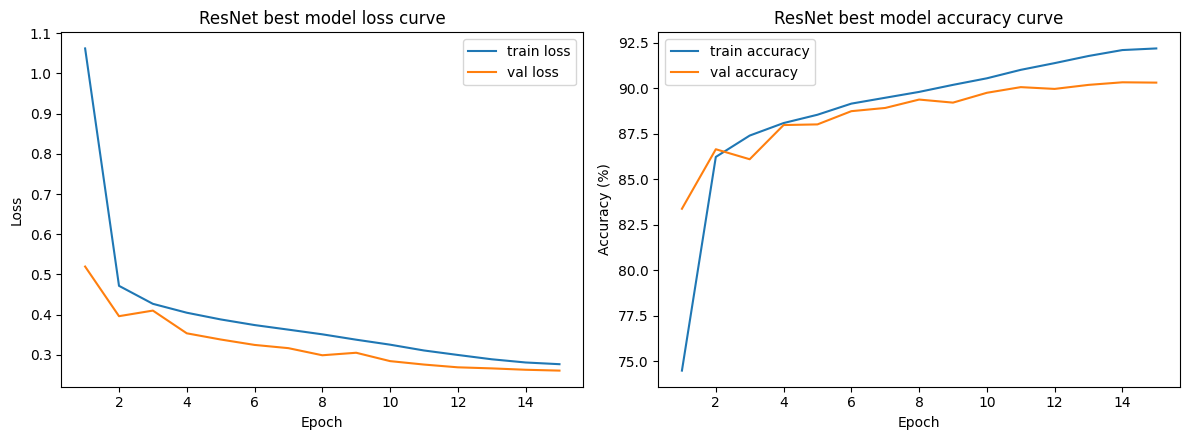


ResNet best run summary
{'model': 'resnet', 'best_epoch': 14, 'best_val_acc': 90.33, 'test_acc': 90.16, 'test_loss': 0.2788, 'training_seconds': 2183.07, 'cpu_peak_rss_mb': None, 'gpu_peak_allocated_mb': None, 'gpu_peak_reserved_mb': None}


[{'model': 'resnet',
  'best_epoch': 14,
  'best_val_acc': 90.33,
  'test_acc': 90.16,
  'test_loss': 0.2788,
  'training_seconds': 2183.07,
  'cpu_peak_rss_mb': None,
  'gpu_peak_allocated_mb': None,
  'gpu_peak_reserved_mb': None}]

In [12]:
# Step 5.c: 读取 best run，绘制 ResNet 的 loss / accuracy 曲线，并汇总训练时间与内存占用。
resnet_bundle = load_best_bundle("resnet")
plot_history_curves(resnet_bundle["history"]["history"], title_prefix="ResNet best model")
show_table([summarize_best_bundle("resnet")], title="ResNet best run summary")



ResNet small-data summary
{'train_ratio_pct': 30, 'run_name': 'resnet_small_30', 'best_epoch': 15, 'best_val_acc': 89.29, 'test_acc': 88.77, 'test_loss': 0.3258, 'training_seconds': 152.05}
{'train_ratio_pct': 50, 'run_name': 'resnet_small_50', 'best_epoch': 15, 'best_val_acc': 90.0, 'test_acc': 89.54, 'test_loss': 0.3011, 'training_seconds': 216.15}
{'train_ratio_pct': 100, 'run_name': 'resnet_small_100', 'best_epoch': 14, 'best_val_acc': 90.38, 'test_acc': 90.14, 'test_loss': 0.2788, 'training_seconds': 395.3}


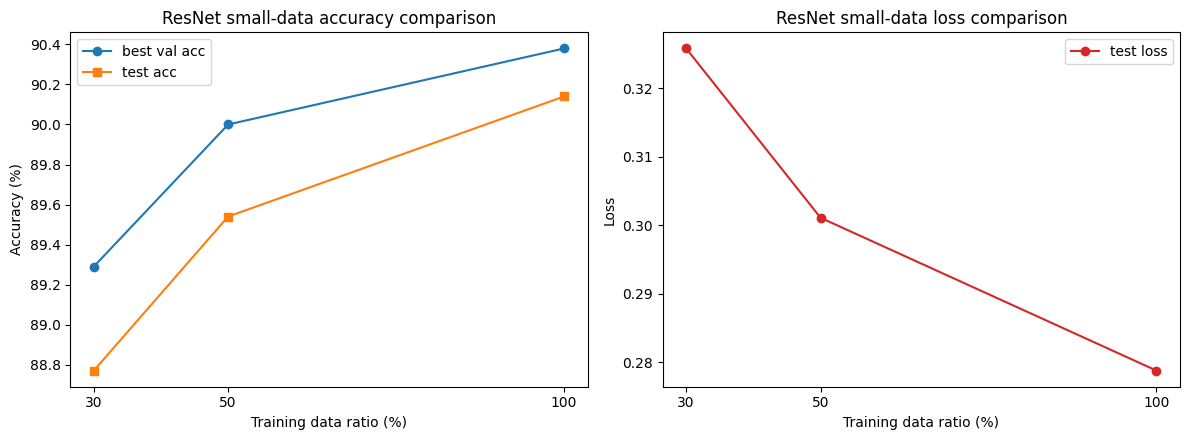


Trend summary:
- test accuracy changes from 88.77% at 30% data to 90.14% at 100% data.
- test loss changes from 0.3258 at 30% data to 0.2788 at 100% data.


In [13]:
# Step 5.d: 展示 ResNet 在 30% / 50% / 100% 训练数据下的小样本结果。
from pathlib import Path
import json
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

RUNS_DIR_LOCAL = Path('runs')


def load_json_local(path):
    return json.loads(Path(path).read_text())


def show_table_local(rows, title=None):
    if title:
        print(f"\n{title}")
    if pd is not None:
        df = pd.DataFrame(rows)
        if display is not None:
            display(df)
        else:
            print(df.to_string(index=False))
        return df
    for row in rows:
        print(row)
    return rows


resnet_small_specs = [
    (30, 'resnet_small_30'),
    (50, 'resnet_small_50'),
    (100, 'resnet_small_100'),
]

resnet_small_rows = []
resnet_small_missing = []

for ratio, run_name in resnet_small_specs:
    run_dir = RUNS_DIR_LOCAL / run_name
    required_files = [run_dir / 'summary.json', run_dir / 'test_metrics.json', run_dir / 'history.json']
    missing_files = [file_path.name for file_path in required_files if not file_path.exists()]
    if missing_files:
        resnet_small_missing.append({'run_name': run_name, 'missing_files': missing_files})
        continue

    summary = load_json_local(run_dir / 'summary.json')
    test_metrics = load_json_local(run_dir / 'test_metrics.json')
    resnet_small_rows.append(
        {
            'train_ratio_pct': ratio,
            'run_name': run_name,
            'best_epoch': summary['best_epoch'],
            'best_val_acc': round(summary['best_val_accuracy'] * 100, 2),
            'test_acc': round(test_metrics['accuracy'] * 100, 2),
            'test_loss': round(test_metrics['loss'], 4),
            'training_seconds': round(summary['training_seconds'], 2),
        }
    )

if resnet_small_missing:
    print('The following ResNet small-data runs are incomplete or missing:')
    for item in resnet_small_missing:
        print(f"- {item['run_name']}: missing {', '.join(item['missing_files'])}")

if resnet_small_rows:
    resnet_small_rows = sorted(resnet_small_rows, key=lambda row: row['train_ratio_pct'])
    show_table_local(resnet_small_rows, title='ResNet small-data summary')

    x = [row['train_ratio_pct'] for row in resnet_small_rows]
    val_acc = [row['best_val_acc'] for row in resnet_small_rows]
    test_acc = [row['test_acc'] for row in resnet_small_rows]
    test_loss = [row['test_loss'] for row in resnet_small_rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(x, val_acc, marker='o', label='best val acc')
    axes[0].plot(x, test_acc, marker='s', label='test acc')
    axes[0].set_xlabel('Training data ratio (%)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('ResNet small-data accuracy comparison')
    axes[0].set_xticks(x)
    axes[0].legend()

    axes[1].plot(x, test_loss, marker='o', color='tab:red', label='test loss')
    axes[1].set_xlabel('Training data ratio (%)')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('ResNet small-data loss comparison')
    axes[1].set_xticks(x)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    if len(resnet_small_rows) >= 2:
        first = resnet_small_rows[0]
        last = resnet_small_rows[-1]
        print()
        print('Trend summary:')
        print(
            f"- test accuracy changes from {first['test_acc']:.2f}% at {first['train_ratio_pct']}% data "
            f"to {last['test_acc']:.2f}% at {last['train_ratio_pct']}% data."
        )
        print(
            f"- test loss changes from {first['test_loss']:.4f} at {first['train_ratio_pct']}% data "
            f"to {last['test_loss']:.4f} at {last['train_ratio_pct']}% data."
        )
else:
    print('No completed ResNet small-data runs were found in runs/.')


## e. Vision Transformer


In [14]:
# ViT 模型实现（直接对应 models/vit.py）
from __future__ import annotations

import math

import torch
from torch import nn


def build_activation(name: str) -> nn.Module:
    key = name.lower()
    if key == "relu":
        return nn.ReLU()
    if key == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.1)
    if key == "elu":
        return nn.ELU()
    if key == "gelu":
        return nn.GELU()
    if key == "silu":
        return nn.SiLU()
    raise ValueError(f"Unsupported activation: {name}")


class TokenBatchNorm(nn.Module):
    def __init__(self, embed_dim: int) -> None:
        super().__init__()
        self.norm = nn.BatchNorm1d(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch, tokens, embed_dim]
        x = x.transpose(1, 2)
        x = self.norm(x)
        return x.transpose(1, 2)


def build_token_norm(name: str, embed_dim: int) -> nn.Module:
    key = name.lower()
    if key == "none":
        return nn.Identity()
    if key == "layernorm":
        return nn.LayerNorm(embed_dim)
    if key == "batchnorm":
        return TokenBatchNorm(embed_dim)
    raise ValueError(f"Unsupported normalization: {name}")


class MLPBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        mlp_dim: int,
        activation: str = "gelu",
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, mlp_dim)
        self.act = build_activation(activation)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(mlp_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        mlp_dim: int,
        activation: str = "gelu",
        norm: str = "layernorm",
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
    ) -> None:
        super().__init__()
        self.norm1 = build_token_norm(norm, embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attention_dropout,
            batch_first=True,
        )
        self.drop_path1 = nn.Dropout(dropout)

        self.norm2 = build_token_norm(norm, embed_dim)
        self.mlp = MLPBlock(
            embed_dim=embed_dim,
            mlp_dim=mlp_dim,
            activation=activation,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm1(x)
        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = residual + self.drop_path1(attn_out)

        residual = x
        x = self.norm2(x)
        x = residual + self.mlp(x)
        return x


class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size: int = 28,
        patch_size: int = 4,
        in_channels: int = 1,
        embed_dim: int = 128,
    ) -> None:
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError(
                f"image_size ({image_size}) must be divisible by patch_size ({patch_size})."
            )

        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size * self.grid_size

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # [B, C, H, W] -> [B, num_patches, embed_dim]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class ViT(nn.Module):
    def __init__(
        self,
        num_classes: int = 47,
        image_size: int = 28,
        patch_size: int = 4,
        in_channels: int = 1,
        embed_dim: int = 128,
        depth: int = 6,
        num_heads: int = 4,
        mlp_ratio: float = 4.0,
        activation: str = "gelu",
        norm: str = "layernorm",
        dropout: float = 0.1,
        attention_dropout: float = 0.0,
        classifier: str = "cls",
    ) -> None:
        super().__init__()

        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})."
            )

        self.classifier = classifier.lower()
        if self.classifier not in {"cls", "mean"}:
            raise ValueError("classifier must be either 'cls' or 'mean'.")

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
        )
        num_patches = self.patch_embed.num_patches
        token_count = num_patches + (1 if self.classifier == "cls" else 0)

        if self.classifier == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        else:
            self.register_parameter("cls_token", None)

        self.pos_embed = nn.Parameter(torch.zeros(1, token_count, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        mlp_dim = int(embed_dim * mlp_ratio)
        self.encoder = nn.Sequential(
            *[
                TransformerEncoderBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim,
                    activation=activation,
                    norm=norm,
                    dropout=dropout,
                    attention_dropout=attention_dropout,
                )
                for _ in range(depth)
            ]
        )

        self.final_norm = build_token_norm(norm, embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self) -> None:
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Conv2d):
                fan_out = module.kernel_size[0] * module.kernel_size[1] * module.out_channels
                fan_out //= module.groups
                module.weight.data.normal_(0.0, math.sqrt(2.0 / fan_out))
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, (nn.LayerNorm, nn.BatchNorm1d)):
                if hasattr(module, "weight") and module.weight is not None:
                    nn.init.ones_(module.weight)
                if hasattr(module, "bias") and module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)

        if self.cls_token is not None:
            cls_token = self.cls_token.expand(x.size(0), -1, -1)
            x = torch.cat([cls_token, x], dim=1)

        x = x + self.pos_embed
        x = self.pos_drop(x)
        x = self.encoder(x)
        x = self.final_norm(x)

        if self.classifier == "cls":
            x = x[:, 0]
        else:
            x = x.mean(dim=1)

        return self.head(x)

### ViT 最优配置

配置来源：`artifacts/best_runs/vit/config.yaml`

```yaml
seed: 42
device: auto

data:
  batch_size: 128
  val_ratio: 0.1
  num_workers: 0

model:
  file: models/vit.py
  class_name: ViT
  kwargs:
    image_size: 28
    patch_size: 4
    in_channels: 1
    embed_dim: 128
    depth: 6
    num_heads: 4
    mlp_ratio: 4.0
    activation: gelu
    norm: none
    dropout: 0.1
    attention_dropout: 0.0
    classifier: cls

train:
  run_name: stage6_gelu_adamw_none_01_cosine_none
  epochs: 30
  optimizer:
    name: adamw
    lr: 0.001
    weight_decay: 0.0001
    momentum: 0.9
  scheduler:
    name: cosine
    min_lr: 0.00001
    t_max: 30
  regularization:
    type: none
    l1_lambda: 0.0
    l2_lambda: 0.0
```


### ViT 训练框架与探索过程

训练同样统一复用项目公共框架：`src/dataset.py + src/trainer.py + src/main.py`。组员在本地训练后，将最佳结果归档到 `artifacts/best_runs/vit/`。

ViT 的调参过程依据 [docs/vit_tuning_summary.md](/home/yanyu/homework/cv/cv-emnist/docs/vit_tuning_summary.md) 简要总结如下：
- 初始 baseline 使用 `gelu + adamw + step + layernorm + dropout(0.1) + no regularization`
- 第一轮先比较激活函数，最终保留 `gelu`
- 第二轮比较优化器，`adamw` 明显优于 `sgd` 和 `rmsprop`
- 第三轮继续比较正则化和 Dropout，最终保留 `no regularization + dropout(0.1)`
- 第四轮比较学习率调度器，最终保留 `cosine`
- 第五轮比较归一化方式，最终保留 `norm = none`
- 还补充测试了结构参数，`patch_size = 7` 单独表现较强，但整体仍低于最终最佳配置，因此最终保留 `patch_size = 4`
- 最终测试准确率从 baseline 的 `86.16%` 提升到 `89.30%`，提升 `3.14` 个百分点
- 下面继续展示 ViT 在 30% / 50% / 100% 训练数据下的小样本结果；如果对应 run 还未生成，单元格会直接提示缺失情况


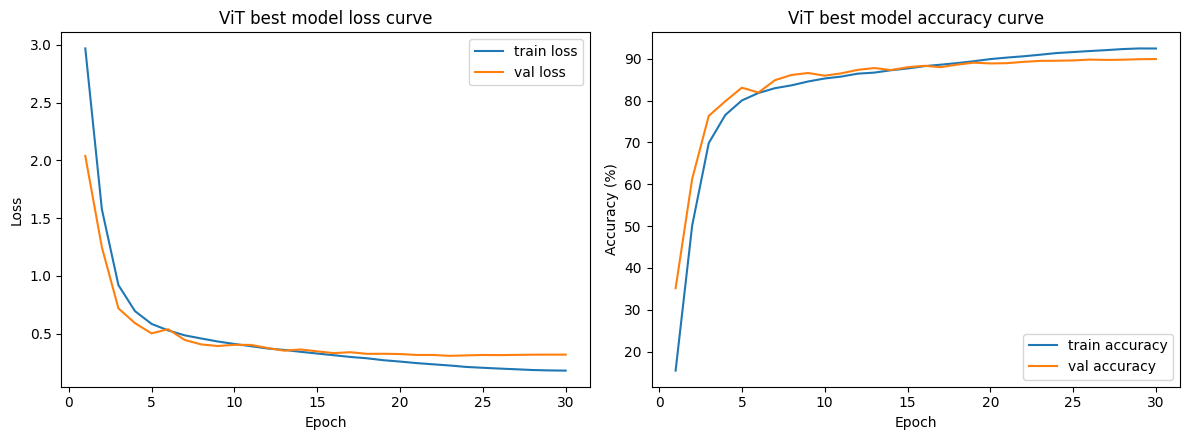


ViT best run summary
{'model': 'vit', 'best_epoch': 30, 'best_val_acc': 89.94, 'test_acc': 89.3, 'test_loss': 0.3346, 'training_seconds': 8778.73, 'cpu_peak_rss_mb': 1449.48, 'gpu_peak_allocated_mb': None, 'gpu_peak_reserved_mb': None}


[{'model': 'vit',
  'best_epoch': 30,
  'best_val_acc': 89.94,
  'test_acc': 89.3,
  'test_loss': 0.3346,
  'training_seconds': 8778.73,
  'cpu_peak_rss_mb': 1449.48,
  'gpu_peak_allocated_mb': None,
  'gpu_peak_reserved_mb': None}]

In [15]:
# Step 5.c: 读取 best run，绘制 ViT 的 loss / accuracy 曲线，并汇总训练时间与内存占用。
vit_bundle = load_best_bundle("vit")
plot_history_curves(vit_bundle["history"]["history"], title_prefix="ViT best model")
show_table([summarize_best_bundle("vit")], title="ViT best run summary")



ViT small-data summary
{'train_ratio_pct': 30, 'run_name': 'vit_small_30', 'best_epoch': 30, 'best_val_acc': 85.46, 'test_acc': 85.12, 'test_loss': 0.485, 'training_seconds': 162.57}
{'train_ratio_pct': 50, 'run_name': 'vit_small_50', 'best_epoch': 30, 'best_val_acc': 88.06, 'test_acc': 87.32, 'test_loss': 0.4138, 'training_seconds': 276.0}
{'train_ratio_pct': 100, 'run_name': 'vit_small_100', 'best_epoch': 25, 'best_val_acc': 89.77, 'test_acc': 89.28, 'test_loss': 0.333, 'training_seconds': 506.65}


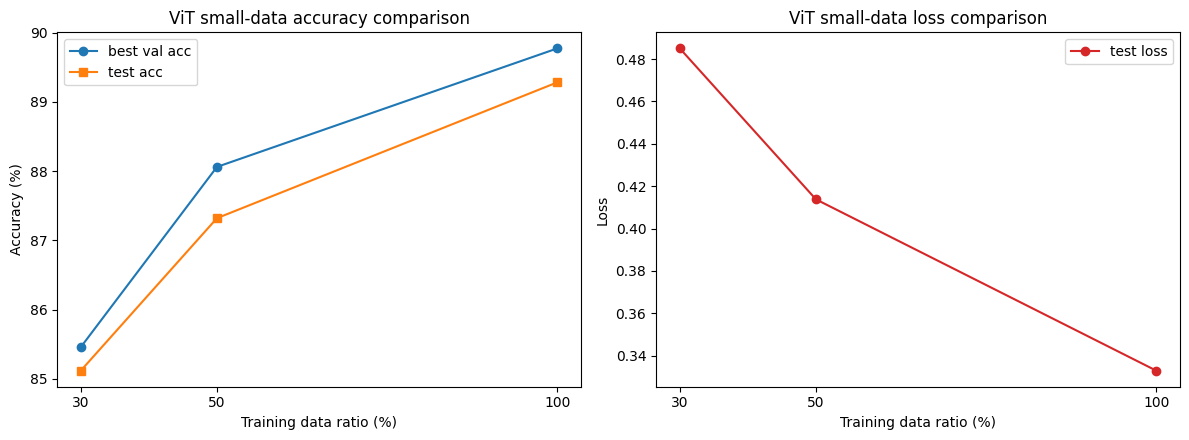


Trend summary:
- test accuracy changes from 85.12% at 30% data to 89.28% at 100% data.
- test loss changes from 0.4850 at 30% data to 0.3330 at 100% data.


In [16]:
# Step 5.d: 展示 ViT 在 30% / 50% / 100% 训练数据下的小样本结果。
from pathlib import Path
import json
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

RUNS_DIR_LOCAL = Path('runs')


def load_json_local(path):
    return json.loads(Path(path).read_text())


def show_table_local(rows, title=None):
    if title:
        print(f"\n{title}")
    if pd is not None:
        df = pd.DataFrame(rows)
        if display is not None:
            display(df)
        else:
            print(df.to_string(index=False))
        return df
    for row in rows:
        print(row)
    return rows


vit_small_specs = [
    (30, 'vit_small_30'),
    (50, 'vit_small_50'),
    (100, 'vit_small_100'),
]

vit_small_rows = []
vit_small_missing = []

for ratio, run_name in vit_small_specs:
    run_dir = RUNS_DIR_LOCAL / run_name
    required_files = [run_dir / 'summary.json', run_dir / 'test_metrics.json', run_dir / 'history.json']
    missing_files = [file_path.name for file_path in required_files if not file_path.exists()]
    if missing_files:
        vit_small_missing.append({'run_name': run_name, 'missing_files': missing_files})
        continue

    summary = load_json_local(run_dir / 'summary.json')
    test_metrics = load_json_local(run_dir / 'test_metrics.json')
    vit_small_rows.append(
        {
            'train_ratio_pct': ratio,
            'run_name': run_name,
            'best_epoch': summary['best_epoch'],
            'best_val_acc': round(summary['best_val_accuracy'] * 100, 2),
            'test_acc': round(test_metrics['accuracy'] * 100, 2),
            'test_loss': round(test_metrics['loss'], 4),
            'training_seconds': round(summary['training_seconds'], 2),
        }
    )

if vit_small_missing:
    print('The following ViT small-data runs are incomplete or missing:')
    for item in vit_small_missing:
        print(f"- {item['run_name']}: missing {', '.join(item['missing_files'])}")

if vit_small_rows:
    vit_small_rows = sorted(vit_small_rows, key=lambda row: row['train_ratio_pct'])
    show_table_local(vit_small_rows, title='ViT small-data summary')

    x = [row['train_ratio_pct'] for row in vit_small_rows]
    val_acc = [row['best_val_acc'] for row in vit_small_rows]
    test_acc = [row['test_acc'] for row in vit_small_rows]
    test_loss = [row['test_loss'] for row in vit_small_rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(x, val_acc, marker='o', label='best val acc')
    axes[0].plot(x, test_acc, marker='s', label='test acc')
    axes[0].set_xlabel('Training data ratio (%)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('ViT small-data accuracy comparison')
    axes[0].set_xticks(x)
    axes[0].legend()

    axes[1].plot(x, test_loss, marker='o', color='tab:red', label='test loss')
    axes[1].set_xlabel('Training data ratio (%)')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('ViT small-data loss comparison')
    axes[1].set_xticks(x)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    if len(vit_small_rows) >= 2:
        first = vit_small_rows[0]
        last = vit_small_rows[-1]
        print()
        print('Trend summary:')
        print(
            f"- test accuracy changes from {first['test_acc']:.2f}% at {first['train_ratio_pct']}% data "
            f"to {last['test_acc']:.2f}% at {last['train_ratio_pct']}% data."
        )
        print(
            f"- test loss changes from {first['test_loss']:.4f} at {first['train_ratio_pct']}% data "
            f"to {last['test_loss']:.4f} at {last['train_ratio_pct']}% data."
        )
else:
    print('No completed ViT small-data runs were found in runs/.')


## f. Step 6

本部分展示四个最佳模型在公共实验中的统一结果。这里不重新训练模型，只读取公共脚本已经保存到 `artifacts` 的结构化结果，并在 notebook 中重新绘制表格和图像。


### Step 6.a 测试集统一评估与对比

本部分比较 `MLP / CNN / ResNet / ViT` 在测试集上的统一指标，并展示模型参数量、前 6 个测试样本预测结果和混淆矩阵。


Metrics summary
{'model_name': 'ResNet', 'accuracy': '0.9016489361702128', 'precision': '0.9020737058745453', 'recall': '0.9016489361702127', 'f1': '0.9013960573678814'}
{'model_name': 'ViT', 'accuracy': '0.893031914893617', 'precision': '0.8936715076455457', 'recall': '0.8930319148936171', 'f1': '0.8922760211349586'}
{'model_name': 'CNN', 'accuracy': '0.8913829787234042', 'precision': '0.8920234748227674', 'recall': '0.8913829787234042', 'f1': '0.8907766374544371'}
{'model_name': 'MLP', 'accuracy': '0.8864893617021277', 'precision': '0.8894646545952402', 'recall': '0.8864893617021278', 'f1': '0.8850641434741884'}


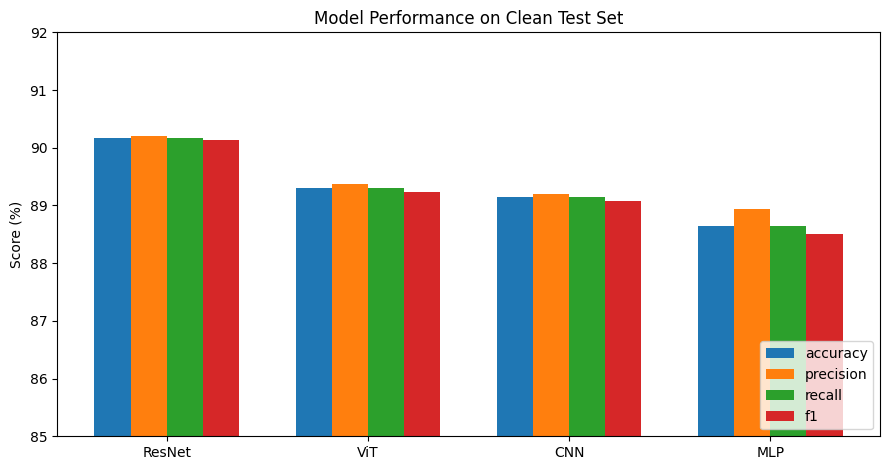

Parameter summary
{'model_name': 'MLP', 'parameters': '573999'}
{'model_name': 'CNN', 'parameters': '834159'}
{'model_name': 'ResNet', 'parameters': '172239'}
{'model_name': 'ViT', 'parameters': '1201327'}


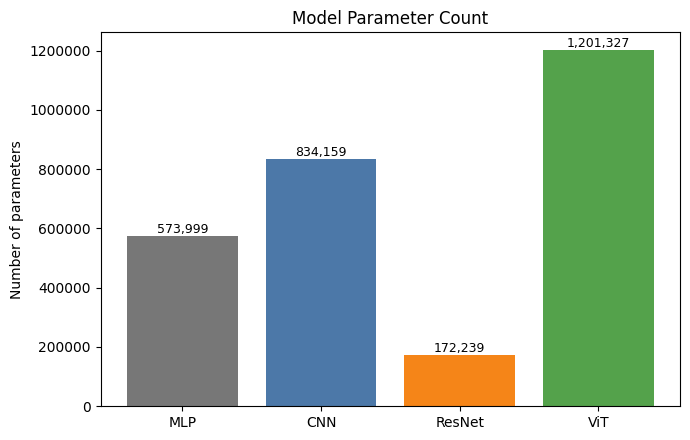

Top 6 predictions
{'sample_index': '0', 'true_label': 'g', 'MLP': 'g', 'CNN': 'g', 'ResNet': 'g', 'ViT': 'g'}
{'sample_index': '1', 'true_label': 'e', 'MLP': 'e', 'CNN': 'e', 'ResNet': 'e', 'ViT': 'e'}
{'sample_index': '2', 'true_label': '9', 'MLP': '9', 'CNN': '9', 'ResNet': '9', 'ViT': '9'}
{'sample_index': '3', 'true_label': 'Q', 'MLP': 'Q', 'CNN': 'Q', 'ResNet': 'Q', 'ViT': 'Q'}
{'sample_index': '4', 'true_label': 'q', 'MLP': '9', 'CNN': '9', 'ResNet': 'q', 'ViT': 'q'}
{'sample_index': '5', 'true_label': 'X', 'MLP': 'X', 'CNN': 'X', 'ResNet': 'X', 'ViT': 'X'}


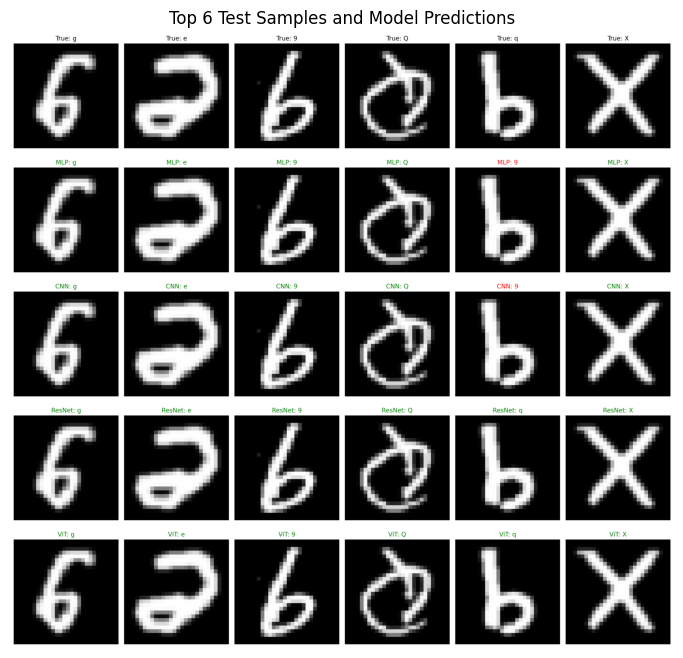

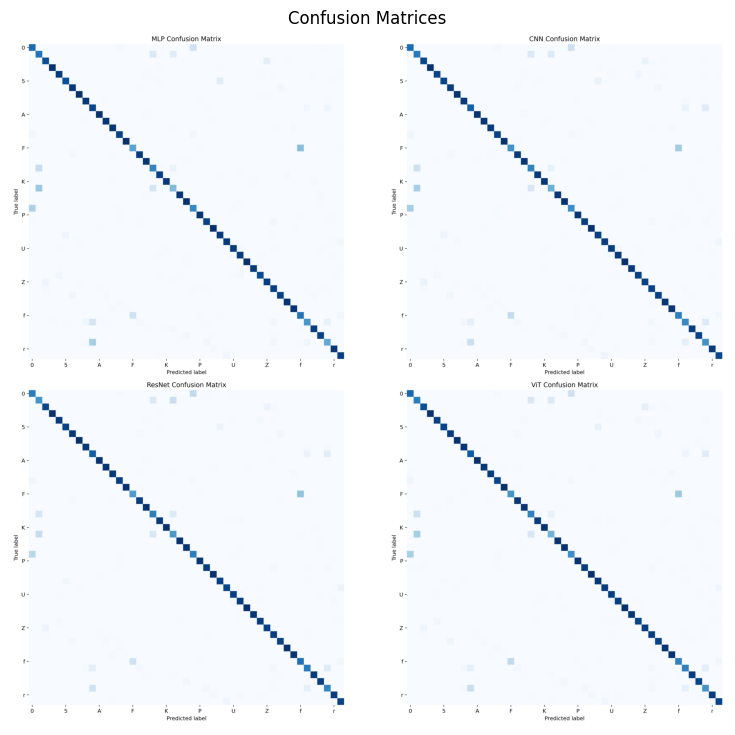

In [1]:
# Step 6.a: 读取公共评估结果，并在 notebook 中绘制指标图和样本预测图。
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

SIX_A_DIR = Path('artifacts/6.a')


def read_csv_rows(path):
    with Path(path).open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))


def show_rows(rows, title):
    print(title)
    if pd is not None and display is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

metrics_rows = read_csv_rows(SIX_A_DIR / 'metrics_summary.csv')
parameter_rows = read_csv_rows(SIX_A_DIR / 'parameter_summary.csv')
top6_rows = read_csv_rows(SIX_A_DIR / 'top6_predictions.csv')

show_rows(metrics_rows, 'Metrics summary')

metric_names = ['accuracy', 'precision', 'recall', 'f1']
model_names = [row['model_name'] for row in metrics_rows]
metric_values = np.array([[float(row[name]) * 100 for name in metric_names] for row in metrics_rows])

x = np.arange(len(model_names))
width = 0.18
fig, ax = plt.subplots(figsize=(9, 4.8))
for offset, metric_name in enumerate(metric_names):
    ax.bar(x + (offset - 1.5) * width, metric_values[:, offset], width=width, label=metric_name)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance on Clean Test Set')
ax.set_ylim(85, 92)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

show_rows(parameter_rows, 'Parameter summary')

param_models = [row['model_name'] for row in parameter_rows]
param_values = [int(row['parameters']) for row in parameter_rows]
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(param_models, param_values, color=['#777777', '#4C78A8', '#F58518', '#54A24B'])
ax.set_ylabel('Number of parameters')
ax.set_title('Model Parameter Count')
ax.ticklabel_format(axis='y', style='plain')
for bar, value in zip(bars, param_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

show_rows(top6_rows, 'Top 6 predictions')

if 'test_dataset' in globals():
    fig, axes = plt.subplots(1, len(top6_rows), figsize=(2.4 * len(top6_rows), 3.4))
    axes = np.atleast_1d(axes)
    for ax, row in zip(axes, top6_rows):
        image, _ = test_dataset[int(row['sample_index'])]
        title = '\n'.join([
            f"True: {row['true_label']}",
            f"MLP:{row['MLP']} CNN:{row['CNN']}",
            f"ResNet:{row['ResNet']} ViT:{row['ViT']}",
        ])
        ax.imshow(image.squeeze(0), cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.suptitle('Top 6 Test Samples and Model Predictions')
    plt.tight_layout()
    plt.show()
else:
    image = plt.imread(SIX_A_DIR / 'top6_predictions.png')
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title('Top 6 Test Samples and Model Predictions')
    plt.show()

# 公共脚本没有保存完整 y_true/y_pred，这里用它生成的混淆矩阵图片做 notebook 内展示。
confusion_image = plt.imread(SIX_A_DIR / 'confusion_matrices.png')
plt.figure(figsize=(10, 9))
plt.imshow(confusion_image)
plt.axis('off')
plt.title('Confusion Matrices')
plt.show()


### Step 6.b 可解释性分析

本部分展示同一个测试样本在 `CNN / ResNet / ViT` 上的关注区域。`CNN / ResNet` 使用 feature maps 和 Grad-CAM，`ViT` 使用 attention map。


Selected sample true label: g
{'model': 'CNN', 'predicted_label': 'g', 'confidence': 0.9874, 'extra': 'feature map 64x14x14'}
{'model': 'ResNet', 'predicted_label': 'g', 'confidence': 0.978, 'extra': 'feature map 64x14x14'}
{'model': 'ViT', 'predicted_label': 'g', 'confidence': 0.9783, 'extra': 'patch grid 7x7, patch size 4'}


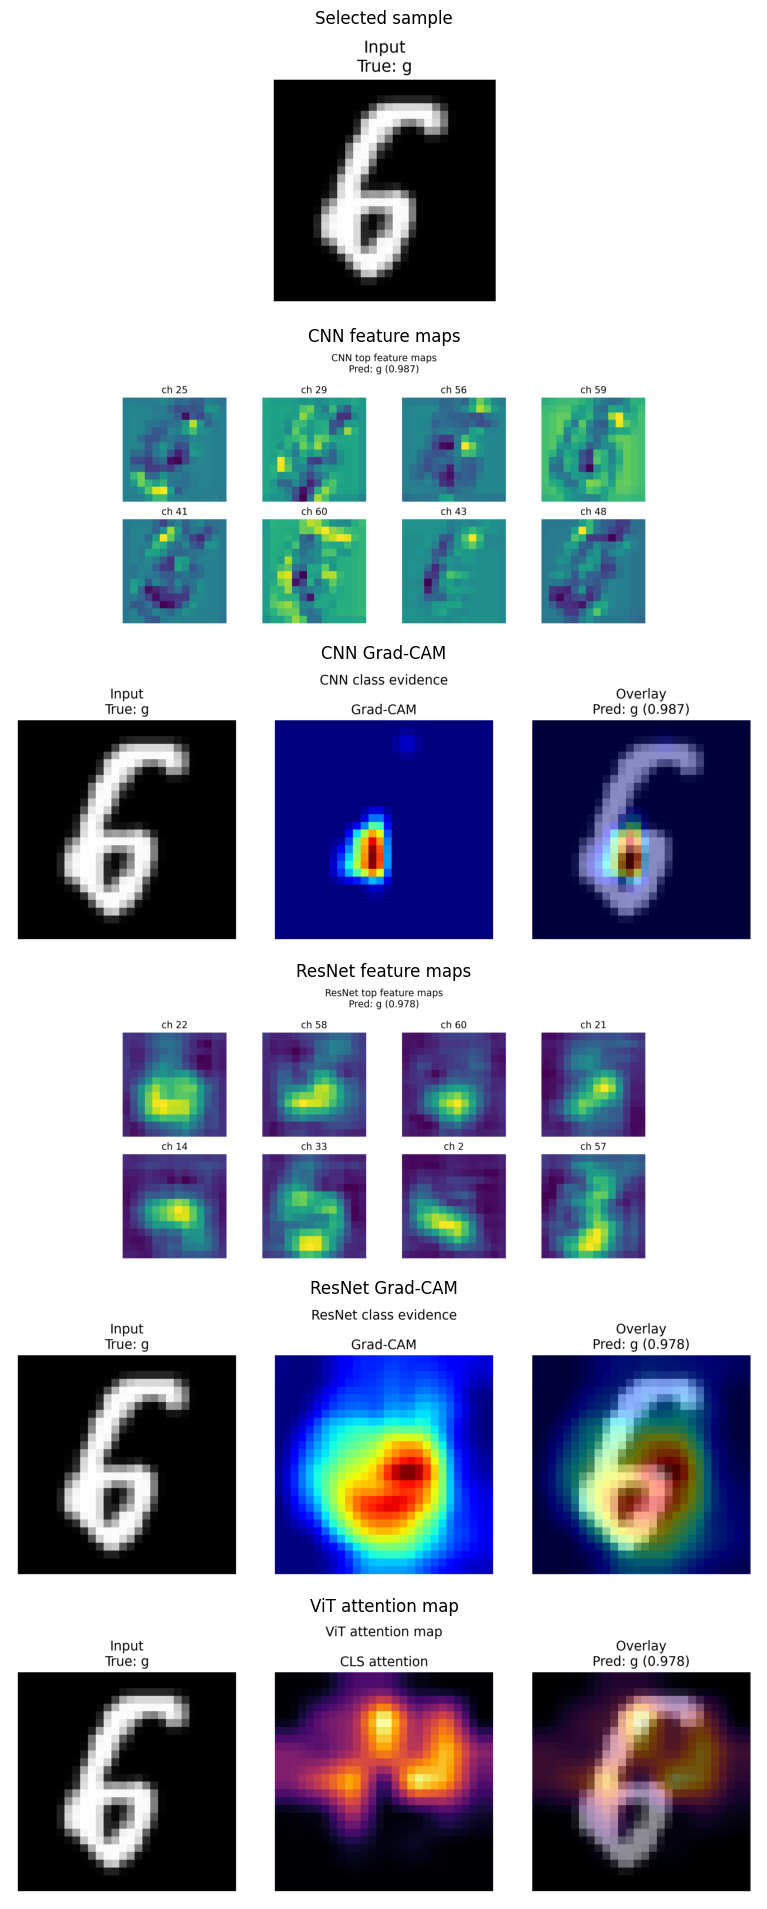

In [2]:
# Step 6.b: 读取可解释性结果，并用 matplotlib 在 notebook 中统一排版展示。
from pathlib import Path
import json
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

SIX_B_DIR = Path('artifacts/6.b')
summary = json.loads((SIX_B_DIR / 'prediction_summary.json').read_text())

summary_rows = [
    {'model': 'CNN', 'predicted_label': summary['cnn']['label'], 'confidence': round(summary['cnn']['confidence'], 4), 'extra': f"feature map {summary['cnn']['feature_channels']}x{summary['cnn']['feature_height']}x{summary['cnn']['feature_width']}"},
    {'model': 'ResNet', 'predicted_label': summary['resnet']['label'], 'confidence': round(summary['resnet']['confidence'], 4), 'extra': f"feature map {summary['resnet']['feature_channels']}x{summary['resnet']['feature_height']}x{summary['resnet']['feature_width']}"},
    {'model': 'ViT', 'predicted_label': summary['vit']['label'], 'confidence': round(summary['vit']['confidence'], 4), 'extra': f"patch grid {summary['vit']['patch_grid']}x{summary['vit']['patch_grid']}, patch size {summary['vit']['patch_size']}"},
]
print(f"Selected sample true label: {summary['true_label']}")
if pd is not None and display is not None:
    display(pd.DataFrame(summary_rows))
else:
    for row in summary_rows:
        print(row)

image_specs = [
    ('Selected sample', SIX_B_DIR / 'selected_sample.png'),
    ('CNN feature maps', SIX_B_DIR / 'cnn_feature_maps.png'),
    ('CNN Grad-CAM', SIX_B_DIR / 'cnn_gradcam.png'),
    ('ResNet feature maps', SIX_B_DIR / 'resnet_feature_maps.png'),
    ('ResNet Grad-CAM', SIX_B_DIR / 'resnet_gradcam.png'),
    ('ViT attention map', SIX_B_DIR / 'vit_attention.png'),
]

fig, axes = plt.subplots(len(image_specs), 1, figsize=(11, 3.2 * len(image_specs)))
for ax, (title, path) in zip(axes, image_specs):
    image = plt.imread(path)
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Step 6.c 鲁棒性评估

本部分比较四个模型在旋转、高斯噪声和模糊扰动下的表现。指标表格来自公共评估脚本，图像在 notebook 中根据 CSV 重新绘制。


Clean test metrics
{'model': 'mlp', 'accuracy': '0.886489', 'precision_macro': '0.889465', 'recall_macro': '0.886489', 'f1_macro': '0.885064'}
{'model': 'cnn', 'accuracy': '0.891383', 'precision_macro': '0.892024', 'recall_macro': '0.891383', 'f1_macro': '0.890777'}
{'model': 'resnet', 'accuracy': '0.901649', 'precision_macro': '0.902074', 'recall_macro': '0.901649', 'f1_macro': '0.901396'}
{'model': 'vit', 'accuracy': '0.893032', 'precision_macro': '0.893672', 'recall_macro': '0.893032', 'f1_macro': '0.892276'}
Average robustness drop
{'model': 'mlp', 'avg_drop_all': '0.030437', 'avg_drop_rotation': '0.019433', 'avg_drop_noise': '0.04984', 'avg_drop_blur': '0.008138', 'max_drop': '0.147553'}
{'model': 'cnn', 'avg_drop_all': '0.135786', 'avg_drop_rotation': '0.052252', 'avg_drop_noise': '0.234122', 'avg_drop_blur': '0.064415', 'max_drop': '0.57867'}
{'model': 'resnet', 'avg_drop_all': '0.168901', 'avg_drop_rotation': '0.046223', 'avg_drop_noise': '0.288165', 'avg_drop_blur': '0.114388'

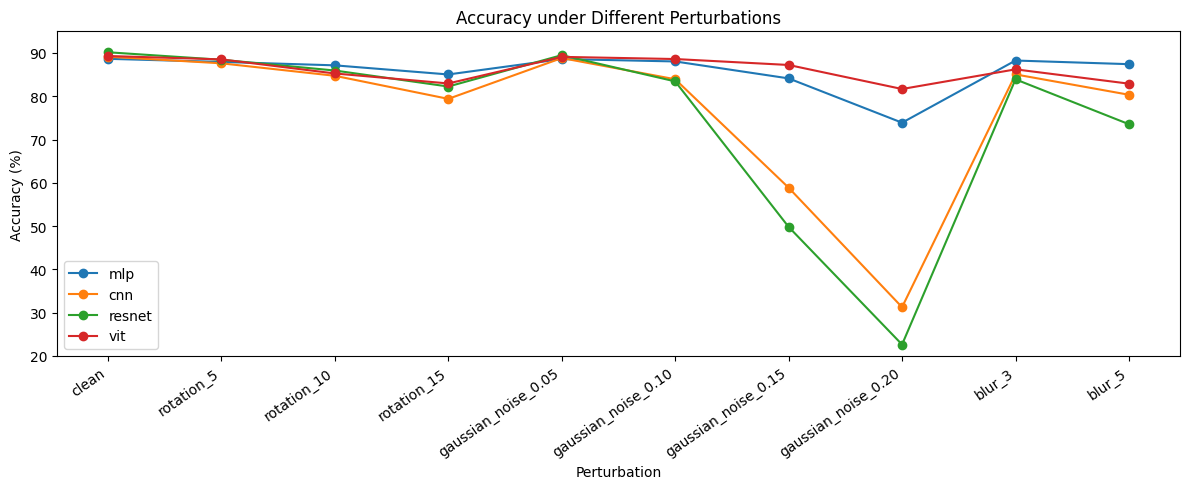

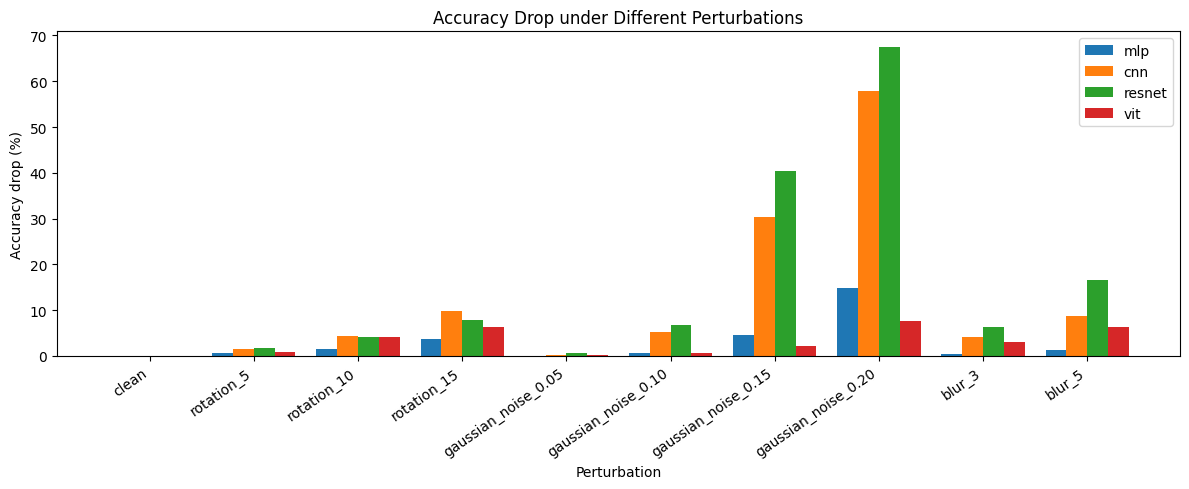

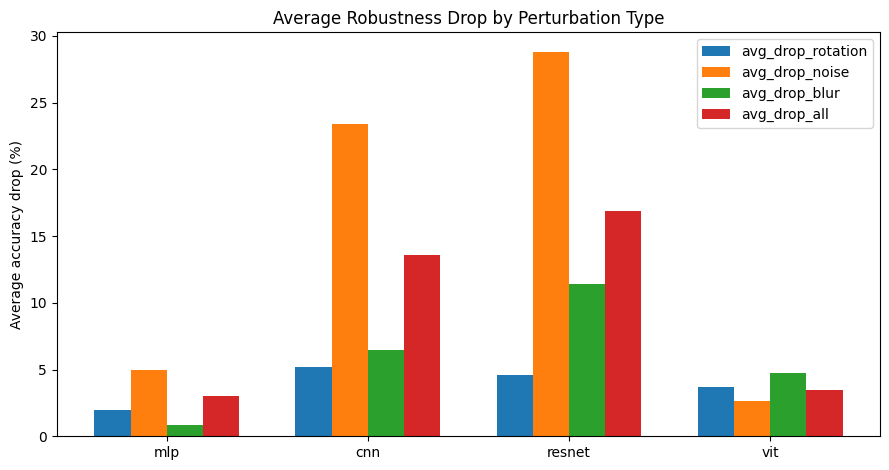

In [3]:
# Step 6.c: 读取鲁棒性评估结果，并在 notebook 中重新绘制 accuracy/drop 图。
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
    from IPython.display import display
except ImportError:
    pd = None
    display = None

SIX_C_DIR = Path('artifacts/6_c')


def read_csv_rows(path):
    with Path(path).open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))


def show_rows(rows, title):
    print(title)
    if pd is not None and display is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

robustness_rows = read_csv_rows(SIX_C_DIR / 'robustness_results.csv')
average_drop_rows = read_csv_rows(SIX_C_DIR / 'robustness_average_drop.csv')

perturbation_order = [
    'clean',
    'rotation_5', 'rotation_10', 'rotation_15',
    'gaussian_noise_0.05', 'gaussian_noise_0.10', 'gaussian_noise_0.15', 'gaussian_noise_0.20',
    'blur_3', 'blur_5',
]
model_order = ['mlp', 'cnn', 'resnet', 'vit']

clean_rows = [
    {key: row[key] for key in ['model', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro']}
    for row in robustness_rows
    if row['perturbation'] == 'clean'
]
show_rows(clean_rows, 'Clean test metrics')
show_rows(average_drop_rows, 'Average robustness drop')

accuracy_by_key = {(row['model'], row['perturbation']): float(row['accuracy']) * 100 for row in robustness_rows}
drop_by_key = {(row['model'], row['perturbation']): float(row['accuracy_drop']) * 100 for row in robustness_rows}

fig, ax = plt.subplots(figsize=(12, 5))
for model in model_order:
    values = [accuracy_by_key[(model, perturbation)] for perturbation in perturbation_order]
    ax.plot(perturbation_order, values, marker='o', label=model)
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Perturbation')
ax.set_title('Accuracy under Different Perturbations')
ax.set_ylim(20, 95)
ax.legend()
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

x = np.arange(len(perturbation_order))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 5))
for offset, model in enumerate(model_order):
    values = [drop_by_key[(model, perturbation)] for perturbation in perturbation_order]
    ax.bar(x + (offset - 1.5) * width, values, width=width, label=model)
ax.set_xticks(x)
ax.set_xticklabels(perturbation_order, rotation=35, ha='right')
ax.set_ylabel('Accuracy drop (%)')
ax.set_xlabel('Perturbation')
ax.set_title('Accuracy Drop under Different Perturbations')
ax.legend()
plt.tight_layout()
plt.show()

avg_metrics = ['avg_drop_rotation', 'avg_drop_noise', 'avg_drop_blur', 'avg_drop_all']
avg_by_model = {row['model']: [float(row[metric]) * 100 for metric in avg_metrics] for row in average_drop_rows}
x = np.arange(len(model_order))
width = 0.18
fig, ax = plt.subplots(figsize=(9, 4.8))
for offset, metric in enumerate(avg_metrics):
    values = [avg_by_model[model][offset] for model in model_order]
    ax.bar(x + (offset - 1.5) * width, values, width=width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(model_order)
ax.set_ylabel('Average accuracy drop (%)')
ax.set_title('Average Robustness Drop by Perturbation Type')
ax.legend()
plt.tight_layout()
plt.show()
